In [1]:
import pandas as pd

In [2]:
auction = pd.read_csv('auction_data.csv')

In [43]:
deliveries = pd.read_csv('deliveries.csv')

In [44]:
matches = pd.read_csv('matches.csv')

In [5]:
auction.head()

,name,country,age,height,role,bat_style,bowl_style,t20_no,t20_runs,t20_avg,...,t20_bowl_econ,t20_bowl_avg,t20_bowl_sr,ipl_wkts,ipl_bowl_econ,ipl_bowl_avg,ipl_bowl_sr,team,year,price
0,chris morris,south africa,26.0,NaN,bowling-allrounder,right-handed-bat,right-arm-fast-medium,4,133,14.78,...,8.40,20.50,14.65,95,8.01,24.16,18.11,chennai-super-kings,2013,36250000
1,dirk nannes,australia,37.0,6.16828,bowler,right-handed-bat,left-arm-fast,3,22,11.00,...,7.52,16.39,13.07,28,7.30,28.04,23.04,chennai-super-kings,2013,34800000
2,ben laughlin,australia,31.0,NaN,bowler,right-handed-bat,right-arm-fast-medium,0,0,0.00,...,9.97,59.00,35.50,10,10.13,28.20,16.70,chennai-super-kings,2013,1160000
3,akila dananjaya,sri lanka,20.0,NaN,bowler,left-handed-bat,right-arm-offbreak,8,65,8.13,...,8.26,32.17,23.37,0,11.75,0.00,0.00,chennai-super-kings,2013,1160000
4,jason holder,west indies,22.0,NaN,bowling-allrounder,right-handed-bat,right-arm-fast-medium,14,491,16.37,...,8.58,28.88,20.20,53,8.81,27.57,18.77,chennai-super-kings,2013,1160000


In [6]:
auction.name.nunique()

588

In [5]:
import pandas as pd

# Load auction + deliveries
auctions = pd.read_csv("auction_data.csv")
deliveries = pd.read_csv("deliveries.csv")

delivery_names = set(deliveries["batsman"].unique()) | set(deliveries["bowler"].unique())
delivery_names

{'A Ashish Reddy',
 'A Badoni',
 'A Chandila',
 'A Choudhary',
 'A Dananjaya',
 'A Kamboj',
 'A Manohar',
 'A Mhatre',
 'A Mishra',
 'A Mithun',
 'A Mukund',
 'A Nehra',
 'A Nortje',
 'A Raghuvanshi',
 'A Tomar',
 'A Zampa',
 'AA Chavan',
 'AA Kulkarni',
 'AB Agarkar',
 'AB Dinda',
 'AB McDonald',
 'AB de Villiers',
 'AC Gilchrist',
 'AD Hales',
 'AD Mascarenhas',
 'AD Mathews',
 'AD Nath',
 'AD Russell',
 'AF Milne',
 'AG Murtaza',
 'AJ Finch',
 'AJ Hosein',
 'AJ Turner',
 'AJ Tye',
 'AK Markram',
 'AL Menaria',
 'AM Nayar',
 'AM Rahane',
 'AN Ahmed',
 'AP Tare',
 'AR Bawne',
 'AR Patel',
 'AS Joseph',
 'AS Rajpoot',
 'AS Roy',
 'AT Carey',
 'AT Rayudu',
 'AU Rashid',
 'Abdul Basith',
 'Abdul Samad',
 'Abhishek Sharma',
 'Abishek Porel',
 'Akash Deep',
 'Akash Madhwal',
 'Akash Singh',
 'Aman Hakim Khan',
 'Anand Rajan',
 'Aniket Verma',
 'Ankit Sharma',
 'Ankit Soni',
 'Anmolpreet Singh',
 'Anuj Rawat',
 'Anureet Singh',
 'Arjun Tendulkar',
 'Arshad Khan',
 'Arshad Khan (2)',
 'Arshd

In [14]:

def match_to_deliveries(name):
    parts = name.strip().split()
    if len(parts) == 1:
        return name  # rare single-name case
    first, last = parts[0], parts[-1]
    candidates = [d for d in delivery_names if d.lower().endswith(last)]
    print(name, candidates)

    if len(candidates) == 0:
        return None
    
    if len(candidates) == 1:
        return candidates[0]
    else:
        # Check initials
        for i in range(len(first)):
            first_initial = first[i].upper()
            for c in candidates:
                if c.startswith(first_initial):
                    return c
            # fallback: return raw last name (debug)
        return None

auctions["matched_name"] = auctions["name"].apply(match_to_deliveries)

# Save mapping for inspection
auctions[["name", "matched_name"]].to_csv("auction_name_to_deliveries.csv", index=False)


chris morris ['CH Morris']
dirk nannes ['DP Nannes']
ben laughlin ['B Laughlin']
akila dananjaya ['A Dananjaya']
jason holder ['JO Holder']
johan botha ['J Botha']
jesse ryder []
jeevan mendis ['BKG Mendis', 'BAW Mendis', 'PHKD Mendis', 'BMAJ Mendis']
manpreet gony ['MS Gony']
luke pomersbach ['LA Pomersbach']
sachithra senanayake ['SMSM Senanayake']
ryan mclaren ['R McLaren']
nathan coulter-nile ['NM Coulter-Nile']
ricky ponting ['RT Ponting']
phillip hughes []
jacob oram ['JDP Oram']
ajantha mendis ['BKG Mendis', 'BAW Mendis', 'PHKD Mendis', 'BMAJ Mendis']
kane richardson ['KW Richardson', 'JA Richardson']
abhishek nayar ['AM Nayar']
michael clarke []
james faulkner ['JP Faulkner']
fidel edwards []
kusal perera ['MDKJ Perera', 'NLTC Perera']
jaydev unadkat ['JD Unadkat']
moises henriques ['MC Henriques']
pankaj singh ['Karanveer Singh', 'Simarjeet Singh', 'Arshdeep Singh', 'P Simran Singh', 'Gurkeerat Singh', 'Virat Singh', 'Shashank Singh', 'Akash Singh', 'NB Singh', 'Anmolpreet Sin

In [10]:
auctions["matched_name"]

0            CH Morris
1            DP Nannes
2           B Laughlin
3          A Dananjaya
4            JO Holder
             ...      
1178    kamindu mendis
1179    Zeeshan Ansari
1180       Sachin Baby
1181      Aniket Verma
1182     Atharva Taide
Name: matched_name, Length: 1183, dtype: object

In [24]:
import pandas as pd

names = pd.read_csv("auction_name_to_deliveries.csv")

In [15]:
names.isna().sum()

name              0
matched_name    126
dtype: int64

In [4]:
len(names)

1183

In [12]:
131/1183

0.11073541842772612

In [18]:
names = names.dropna()

In [19]:
names.to_csv("auction_name_to_deliveries.csv")

In [20]:
auction = pd.read_csv("auction_data.csv")

In [31]:
len(auction)

1183

In [37]:
len(names)

495

In [36]:
names = names.drop_duplicates(subset=["name"])


In [38]:
merged = auction.merge(names, how="left", on="name")

In [39]:
len(merged)

1183

In [40]:
cleaned = merged.dropna(subset=["matched_name"])

In [41]:
len(cleaned)

1068

In [42]:
cleaned["name"] = cleaned["matched_name"]

# Drop the extra column (optional)
cleaned = cleaned.drop(columns=["matched_name"])

# Save the cleaned dataset
cleaned.to_csv("auction_data_cleaned.csv", index=False)

C:\Users\91821\AppData\Local\Temp\ipykernel_10056\4082049666.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned["name"] = cleaned["matched_name"]


In [47]:
deliveries.groupby("batsman")

In [46]:
deliveries

,match_id,inning,over,ball,batting_team,batsman,bowler,runs_batsman,runs_extras,runs_total,inning_runs,extras_type,wicket_kind,player_out,inning_wickets
0,1001,1,0,1,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,0,NaN,NaN,NaN,0
1,1001,1,0,2,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,0,NaN,NaN,NaN,0
2,1001,1,0,3,Sunrisers Hyderabad,DA Warner,TS Mills,4,0,4,4,NaN,NaN,NaN,0
3,1001,1,0,4,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,4,NaN,NaN,NaN,0
4,1001,1,0,5,Sunrisers Hyderabad,DA Warner,TS Mills,0,2,2,6,wides,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201827,1847,2,19,2,Royal Challengers Bangalore,Sachin Baby,B Kumar,2,0,2,194,NaN,NaN,NaN,6
201828,1847,2,19,3,Royal Challengers Bangalore,Sachin Baby,B Kumar,0,0,0,194,NaN,run out,CJ Jordan,7
201829,1847,2,19,4,Royal Challengers Bangalore,Iqbal Abdulla,B Kumar,0,1,1,195,legbyes,NaN,NaN,7
201830,1847,2,19,5,Royal Challengers Bangalore,Sachin Baby,B Kumar,1,0,1,196,NaN,NaN,NaN,7


In [48]:
deliveries1 = deliveries.merge(matches, how="left", on="match_id")

In [49]:
deliveries1

,match_id,inning,over,ball,batting_team,batsman,bowler,runs_batsman,runs_extras,runs_total,...,season,date,venue,team1,team2,toss_winner,toss_decision,winner,result,margin
0,1001,1,0,1,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,...,2017,05-04-2017,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,NaN,{'runs': 35}
1,1001,1,0,2,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,...,2017,05-04-2017,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,NaN,{'runs': 35}
2,1001,1,0,3,Sunrisers Hyderabad,DA Warner,TS Mills,4,0,4,...,2017,05-04-2017,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,NaN,{'runs': 35}
3,1001,1,0,4,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,...,2017,05-04-2017,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,NaN,{'runs': 35}
4,1001,1,0,5,Sunrisers Hyderabad,DA Warner,TS Mills,0,2,2,...,2017,05-04-2017,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,NaN,{'runs': 35}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201827,1847,2,19,2,Royal Challengers Bangalore,Sachin Baby,B Kumar,2,0,2,...,2016,29-05-2016,M Chinnaswamy Stadium,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,NaN,{'runs': 8}
201828,1847,2,19,3,Royal Challengers Bangalore,Sachin Baby,B Kumar,0,0,0,...,2016,29-05-2016,M Chinnaswamy Stadium,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,NaN,{'runs': 8}
201829,1847,2,19,4,Royal Challengers Bangalore,Iqbal Abdulla,B Kumar,0,1,1,...,2016,29-05-2016,M Chinnaswamy Stadium,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,NaN,{'runs': 8}
201830,1847,2,19,5,Royal Challengers Bangalore,Sachin Baby,B Kumar,1,0,1,...,2016,29-05-2016,M Chinnaswamy Stadium,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,NaN,{'runs': 8}


In [68]:
import pandas as pd

batsmen = pd.read_csv("C:/Users/91821/Desktop/ipl/batsmen_price.csv")
bowlers = pd.read_csv("C:/Users/91821/Desktop/ipl/bowlers_price_clean.csv")
allrounders = pd.read_csv("C:/Users/91821/Desktop/ipl/allrounders_price.csv")

print(batsmen.head())
print(bowlers.head())
print(allrounders.head())


   season        player  runs     price
0    2013   NLTC Perera   235  39150000
1    2013     DJG Sammy   174  24650000
2    2013  MC Henriques   165  17400000
3    2014    RV Uthappa   660  50000000
4    2014      DR Smith   566  45000000
   season       player  wickets     price
0    2013  JP Faulkner       28  23200000
1    2013  NLTC Perera       19  39150000
2    2013    CH Morris       15  36250000
3    2013   JD Unadkat       13  30450000
4    2014    MM Sharma       23  20000000
   season        player  runs  wickets  allrounder_score     price
0    2013   JP Faulkner    57       28          3.032904  23200000
1    2013   NLTC Perera   235       19          2.822535  39150000
2    2013     DJG Sammy   174        8          0.828732  24650000
3    2013  MC Henriques   165        7          0.625939  17400000
4    2013       MS Gony    45        7         -0.122214  29000000


In [69]:
# Correlation between price and runs
print("Batsmen correlation:", batsmen[["price", "runs"]].corr().iloc[0,1])

# Correlation between price and wickets
print("Bowlers correlation:", bowlers[["price", "wickets"]].corr().iloc[0,1])

# Correlation between price and allrounder score
print("Allrounders correlation:", allrounders[["price", "allrounder_score"]].corr().iloc[0,1])


Batsmen correlation: 0.15185328986666177
Bowlers correlation: 0.1667475765826573
Allrounders correlation: 0.35760252827457545


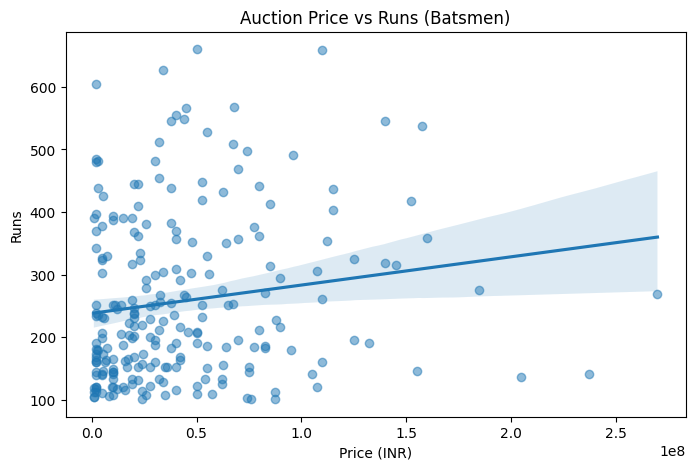

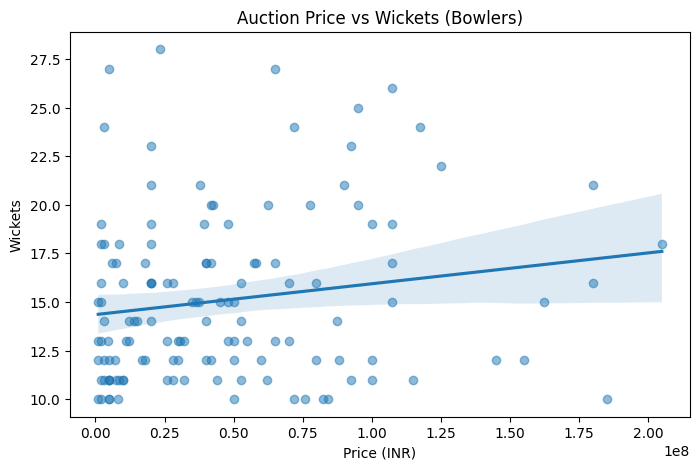

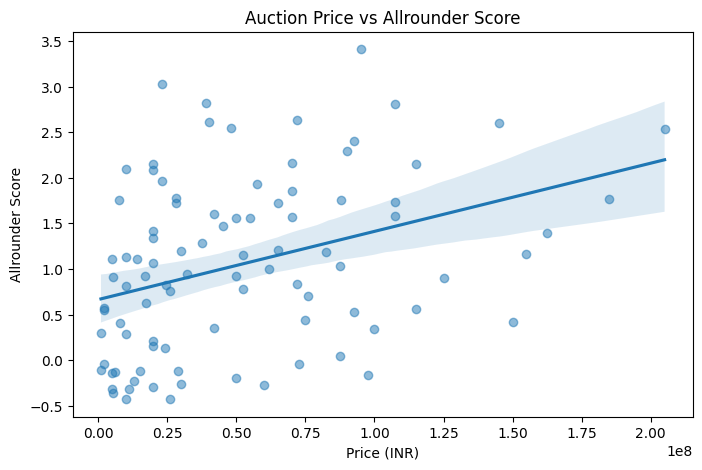

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Batsmen
plt.figure(figsize=(8,5))
sns.regplot(data=batsmen, x="price", y="runs", scatter_kws={'alpha':0.5})
plt.title("Auction Price vs Runs (Batsmen)")
plt.xlabel("Price (INR)")
plt.ylabel("Runs")
plt.show()

# Bowlers
plt.figure(figsize=(8,5))
sns.regplot(data=bowlers, x="price", y="wickets", scatter_kws={'alpha':0.5})
plt.title("Auction Price vs Wickets (Bowlers)")
plt.xlabel("Price (INR)")
plt.ylabel("Wickets")
plt.show()

# Allrounders
plt.figure(figsize=(8,5))
sns.regplot(data=allrounders, x="price", y="allrounder_score", scatter_kws={'alpha':0.5})
plt.title("Auction Price vs Allrounder Score")
plt.xlabel("Price (INR)")
plt.ylabel("Allrounder Score")
plt.show()



In [71]:
# 📌 IPL ROI Analysis Plots
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load Data ---
batsmen = pd.read_csv("C:/Users/91821/Desktop/ipl/batsmen_roi_inflation.csv")
bowlers = pd.read_csv("C:/Users/91821/Desktop/ipl/bowlers_roi_inflation.csv")
allrounders = pd.read_csv("C:/Users/91821/Desktop/ipl/allrounders_roi_inflation.csv")

# Set style
sns.set(style="whitegrid", context="talk")


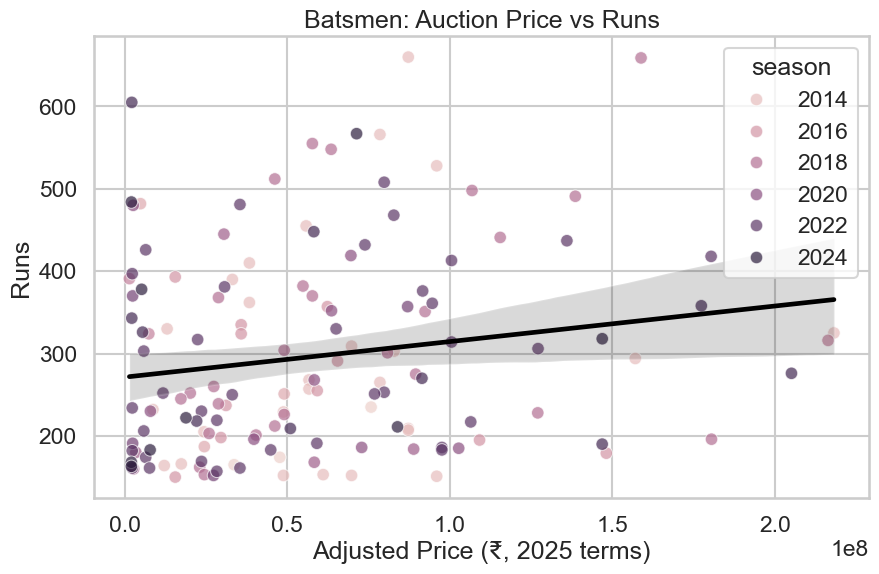

In [73]:
# Scatter: price vs runs
plt.figure(figsize=(10,6))
sns.scatterplot(data=batsmen, x="adj_price", y="runs", hue="season", alpha=0.7)
sns.regplot(data=batsmen, x="adj_price", y="runs", scatter=False, color="black")
plt.title("Batsmen: Auction Price vs Runs")
plt.xlabel("Adjusted Price (₹, 2025 terms)")
plt.ylabel("Runs")
plt.show()

# # Bar: Top 5 batsmen per season
# top_batsmen = batsmen.groupby("season").apply(lambda x: x.nlargest(5, "runs")).reset_index(drop=True)
# plt.figure(figsize=(12,6))
# sns.barplot(data=top_batsmen, x="season", y="runs", hue="player")
# plt.title("Top 5 Batsmen per Season (with Adjusted Price)")
# plt.ylabel("Runs")
# plt.show()


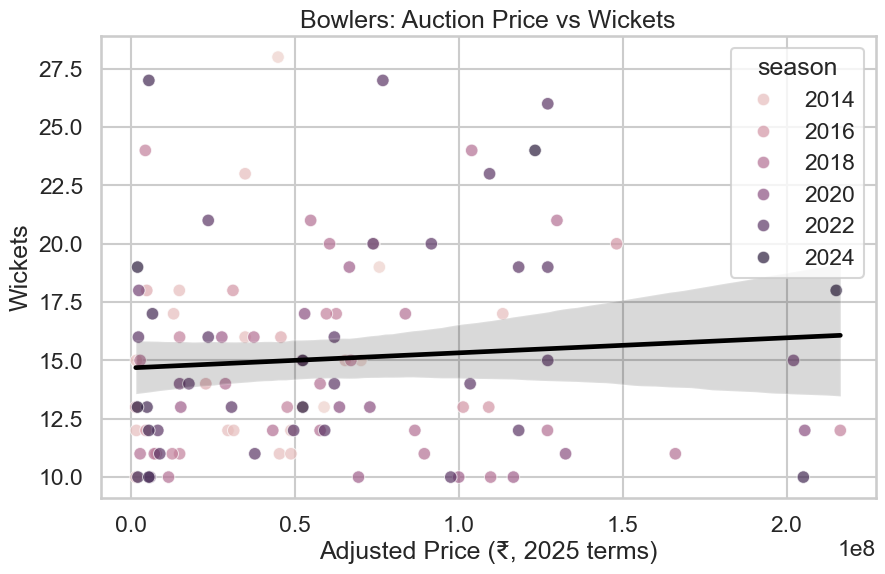

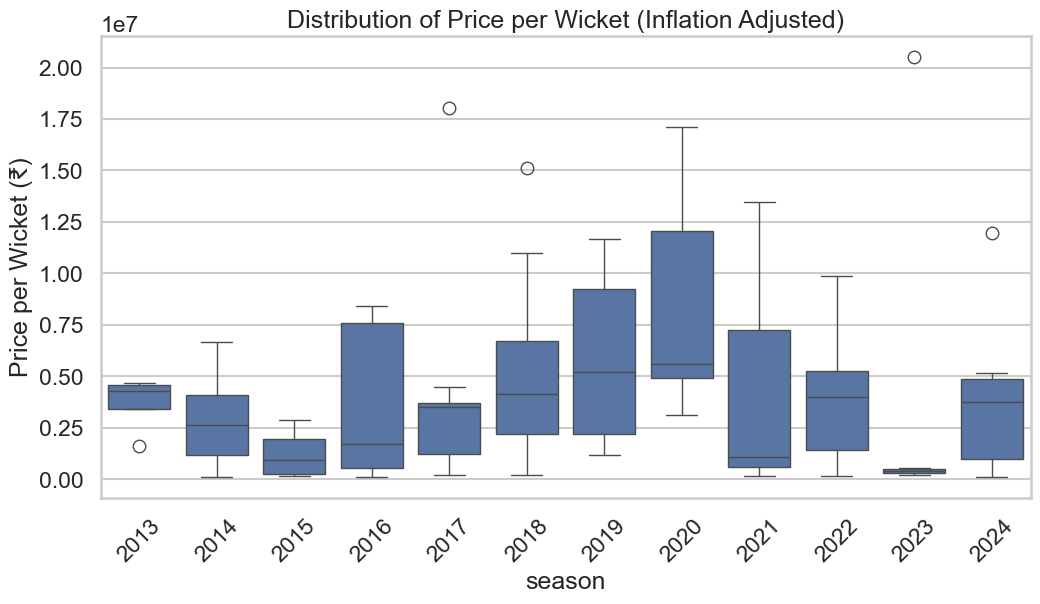

In [74]:
# Scatter: price vs wickets
plt.figure(figsize=(10,6))
sns.scatterplot(data=bowlers, x="adj_price", y="wickets", hue="season", alpha=0.7)
sns.regplot(data=bowlers, x="adj_price", y="wickets", scatter=False, color="black")
plt.title("Bowlers: Auction Price vs Wickets")
plt.xlabel("Adjusted Price (₹, 2025 terms)")
plt.ylabel("Wickets")
plt.show()

# Boxplot: price per wicket distribution
plt.figure(figsize=(12,6))
sns.boxplot(data=bowlers, x="season", y="price_per_wicket_adj")
plt.title("Distribution of Price per Wicket (Inflation Adjusted)")
plt.ylabel("Price per Wicket (₹)")
plt.xticks(rotation=45)
plt.show()


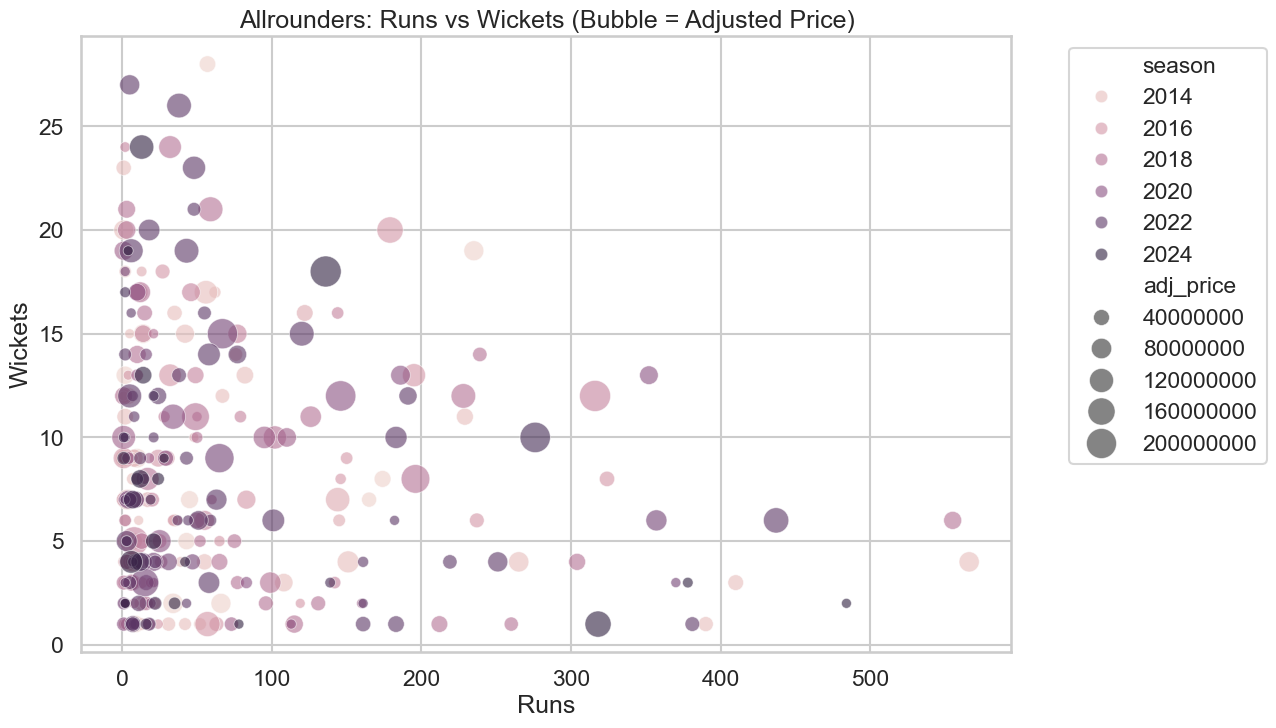

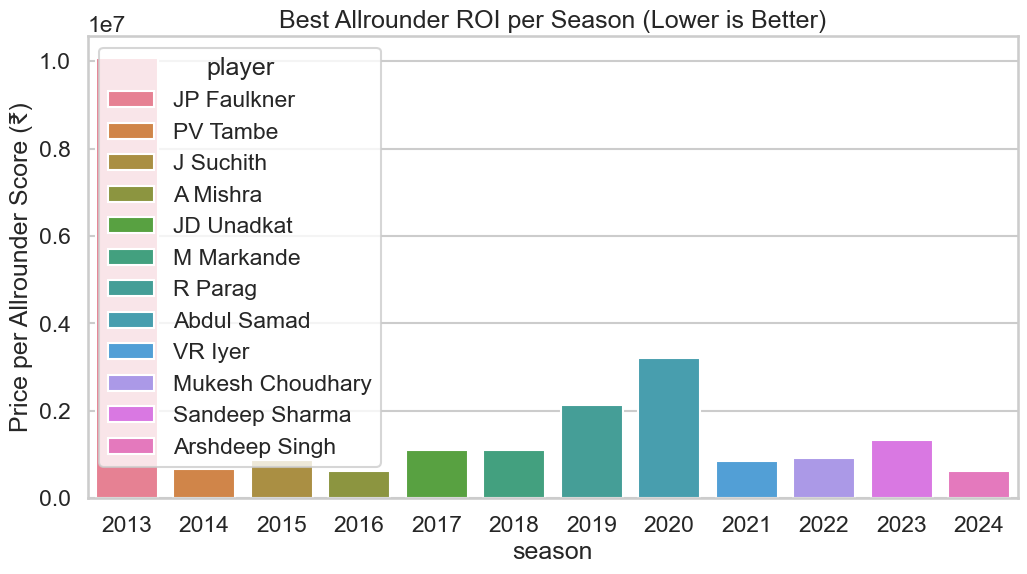

In [75]:
# Bubble plot: runs vs wickets, bubble size = adj_price
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=allrounders, x="runs", y="wickets", size="adj_price",
    hue="season", sizes=(50,500), alpha=0.6
)
plt.title("Allrounders: Runs vs Wickets (Bubble = Adjusted Price)")
plt.xlabel("Runs")
plt.ylabel("Wickets")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Bar: best ROI allrounder per season
best_allrounders = allrounders.loc[allrounders.groupby("season")["price_per_allrounder_score_adj"].idxmin()]
plt.figure(figsize=(12,6))
sns.barplot(data=best_allrounders, x="season", y="price_per_allrounder_score_adj", hue="player")
plt.title("Best Allrounder ROI per Season (Lower is Better)")
plt.ylabel("Price per Allrounder Score (₹)")
plt.show()


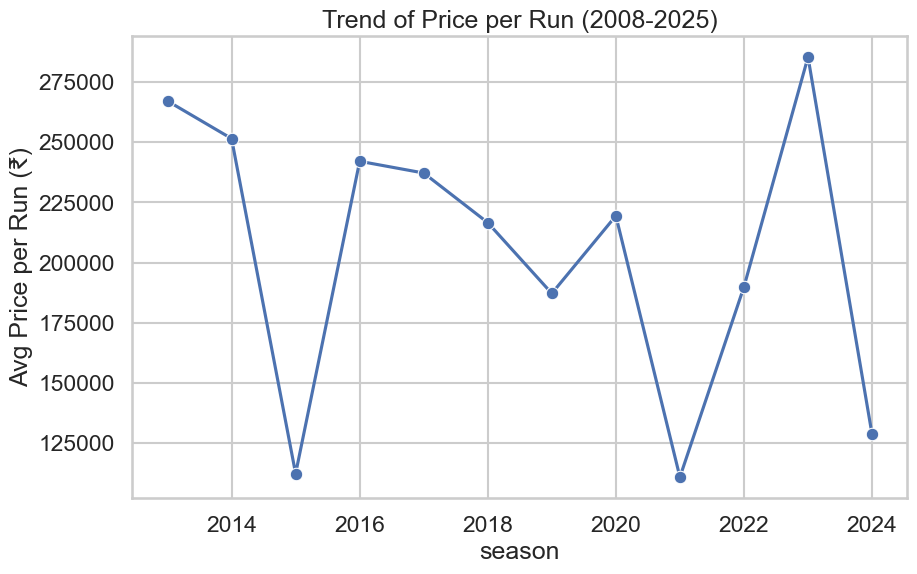

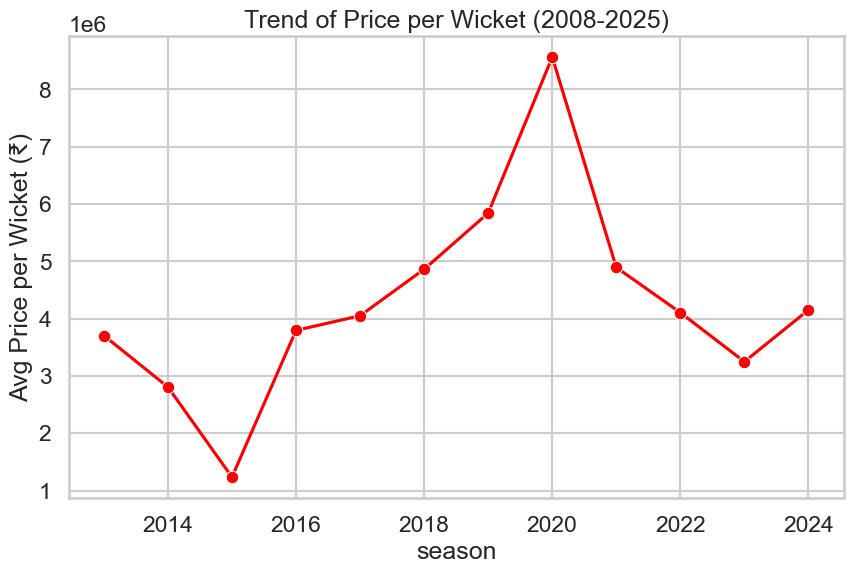

In [76]:
# Avg price_per_run trend
batsmen_trend = batsmen.groupby("season")["price_per_run_adj"].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data=batsmen_trend, x="season", y="price_per_run_adj", marker="o")
plt.title("Trend of Price per Run (2008-2025)")
plt.ylabel("Avg Price per Run (₹)")
plt.show()

# Avg price_per_wicket trend
bowlers_trend = bowlers.groupby("season")["price_per_wicket_adj"].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data=bowlers_trend, x="season", y="price_per_wicket_adj", marker="o", color="red")
plt.title("Trend of Price per Wicket (2008-2025)")
plt.ylabel("Avg Price per Wicket (₹)")
plt.show()


In [84]:
%pip install statsmodel.api

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement statsmodel.api (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for statsmodel.api


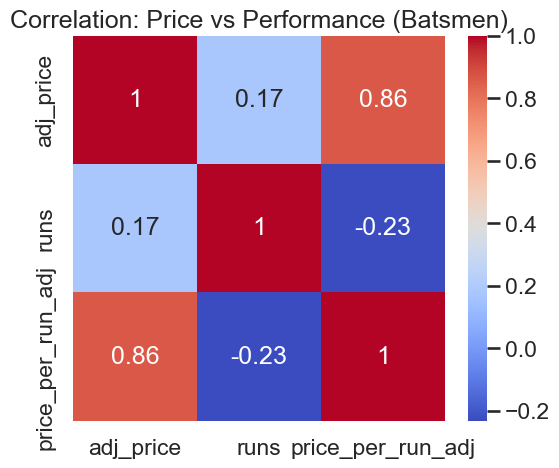

                            OLS Regression Results                            
Dep. Variable:                   runs   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     4.404
Date:                Thu, 02 Oct 2025   Prob (F-statistic):             0.0376
Time:                        05:36:40   Log-Likelihood:                -899.06
No. Observations:                 145   AIC:                             1802.
Df Residuals:                     143   BIC:                             1808.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        271.3261     15.521     17.481      0.0

In [85]:
# Correlation heatmap (Batsmen)
plt.figure(figsize=(6,5))
sns.heatmap(batsmen[["adj_price","runs","price_per_run_adj"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation: Price vs Performance (Batsmen)")
plt.show()

# Regression (quick check)
import statsmodels.api as sm
X = batsmen["adj_price"]
y = batsmen["runs"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


In [82]:
import statsmodels.api as sm
import numpy as np

# Polynomial fit (quadratic)
X = np.column_stack((batsmen["adj_price"], batsmen["adj_price"]**2))
X = sm.add_constant(X)
model_poly = sm.OLS(batsmen["runs"], X).fit()
print(model_poly.summary())


ModuleNotFoundError: No module named 'statsmodels'